# TP — Analyse et prédiction du risque sismique avec les données USGS

## 1. Exploration et prétraitement des données

### Objectif

Ce notebook constitue la première étape du projet.

Nous allons explorer, nettoyer et préparer les données sismiques de l'USGS avant de développer les six modèles de Machine Learning :

1. **Où ?** — Classification de la zone de risque : Faible / Moyen / Élevé
2. **Quelle intensité ?** — Régression du PGA
3. **Pourquoi ?** — Classification des facteurs de risque
4. **Quels dégâts ?** — Classification : Faible / Modéré / Sévère
5. **Quelle action ?** — Classification de l'action recommandée
6. **Combien ?** — Régression des pertes économiques

In [1]:
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Accès aux données USGS
import requests

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


In [5]:
# URL de l'API USGS
url = "https://earthquake.usgs.gov/fdsnws/event/1/query"

periods = [
    ("2025-01-01", "2025-06-30"),
    ("2025-07-01", "2025-12-31")
]

all_features = []

for start, end in periods:
    params = {
        "format": "geojson",
        "starttime": start,
        "endtime": end,
        "minmagnitude": 2.5,
        "orderby": "time"
    }

    response = requests.get(url, params=params)

    print(start, "→", end, "| Status :", response.status_code)

    if response.status_code == 200:
        data_json = response.json()
        features = data_json["features"]

        print("Nombre de séismes :", len(features))

        all_features.extend(features)

print("\nTotal récupéré :", len(all_features))

2025-01-01 → 2025-06-30 | Status : 200
Nombre de séismes : 12788
2025-07-01 → 2025-12-31 | Status : 200
Nombre de séismes : 16274

Total récupéré : 29062


In [6]:
# Transformer les données GeoJSON de l'USGS en DataFrame

records = []

for feature in all_features:
    properties = feature["properties"]
    coordinates = feature["geometry"]["coordinates"]

    record = properties.copy()

    # Informations géographiques
    record["longitude"] = coordinates[0]
    record["latitude"] = coordinates[1]
    record["depth"] = coordinates[2]

    # Identifiant USGS
    record["event_id"] = feature["id"]

    records.append(record)

df = pd.DataFrame(records)

print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

df.head()

Nombre de lignes : 29062
Nombre de colonnes : 30


,mag,place,time,updated,tz,url,detail,felt,cdi,mmi,...,dmin,rms,gap,magType,type,title,longitude,latitude,depth,event_id
0,4.2,"70 km W of Abra Pampa, Argentina",1751241591065,1757018402040,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,...,1.696,0.70,89.0,mb,earthquake,"M 4.2 - 70 km W of Abra Pampa, Argentina",-66.3753,-22.6251,247.528,us7000q9mu
1,2.5,"1 km E of Nikolski, Alaska",1751241495097,1757018405040,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,...,0.035,0.42,198.0,ml,earthquake,"M 2.5 - 1 km E of Nikolski, Alaska",-168.8412,52.9376,61.149,us7000qb5r
2,2.8,"31 km SSE of Nikolski, Alaska",1751241219318,1757018405040,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,...,0.316,0.51,231.0,ml,earthquake,"M 2.8 - 31 km SSE of Nikolski, Alaska",-168.6544,52.6804,35.000,us7000qb5v
3,3.8,"153 km S of Nikolski, Alaska",1751241150341,1757018402040,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,...,1.411,0.42,185.0,mb,earthquake,"M 3.8 - 153 km S of Nikolski, Alaska",-168.5438,51.5761,10.000,us7000q9mt
4,4.5,"185 km WSW of Tual, Indonesia",1751240317514,1757018402040,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,...,3.637,0.48,93.0,mb,earthquake,"M 4.5 - 185 km WSW of Tual, Indonesia",131.2977,-6.4544,35.000,us7000q9mq


In [7]:
# Afficher uniquement les noms des colonnes

print("Nombre total de colonnes :", len(df.columns))

for col in df.columns:
    print(col)

Nombre total de colonnes : 30
mag
place
time
updated
tz
url
detail
felt
cdi
mmi
alert
status
tsunami
sig
net
code
ids
sources
types
nst
dmin
rms
gap
magType
type
title
longitude
latitude
depth
event_id


In [8]:
# Afficher le type de chaque variable

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29062 entries, 0 to 29061
Data columns (total 30 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mag        29062 non-null  float64
 1   place      29062 non-null  str    
 2   time       29062 non-null  int64  
 3   updated    29062 non-null  int64  
 4   tz         0 non-null      object 
 5   url        29062 non-null  str    
 6   detail     29062 non-null  str    
 7   felt       3877 non-null   float64
 8   cdi        3877 non-null   float64
 9   mmi        1990 non-null   float64
 10  alert      904 non-null    str    
 11  status     29062 non-null  str    
 12  tsunami    29062 non-null  int64  
 13  sig        29062 non-null  int64  
 14  net        29062 non-null  str    
 15  code       29062 non-null  str    
 16  ids        29062 non-null  str    
 17  sources    29062 non-null  str    
 18  types      29062 non-null  str    
 19  nst        27765 non-null  float64
 20  dmin       27757 

In [9]:
# Analyse des valeurs manquantes

missing = pd.DataFrame({
    "Valeurs_manquantes": df.isnull().sum(),
    "Pourcentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing.sort_values(
    by="Pourcentage",
    ascending=False
)

missing

,Valeurs_manquantes,Pourcentage
tz,29062,100.00
alert,28158,96.89
mmi,27072,93.15
cdi,25185,86.66
felt,25185,86.66
dmin,1305,4.49
gap,1302,4.48
nst,1297,4.46
url,0,0.00
place,0,0.00


In [10]:
# Vérifier les doublons

print("Nombre de lignes :", len(df))

print(
    "Nombre de lignes complètement dupliquées :",
    df.duplicated().sum()
)

print(
    "Nombre d'identifiants USGS dupliqués :",
    df["event_id"].duplicated().sum()
)

Nombre de lignes : 29062
Nombre de lignes complètement dupliquées : 0
Nombre d'identifiants USGS dupliqués : 0


In [11]:
# Vérifier le nombre d'événements uniques

print("Nombre d'événements uniques :", df["event_id"].nunique())

Nombre d'événements uniques : 29062


In [12]:
# Statistiques descriptives des variables numériques

df.describe().T

,count,mean,std,min,25%,50%,75%,max
mag,29062.0,3.932225e+00,8.447995e-01,2.500000e+00,3.100000e+00,4.200000e+00,4.500000e+00,8.800000e+00
time,29062.0,1.751747e+12,8.863439e+09,1.735690e+12,1.744030e+12,1.752899e+12,1.758624e+12,1.767139e+12
updated,29062.0,1.758446e+12,9.636178e+09,1.735754e+12,1.749476e+12,1.759517e+12,1.765353e+12,1.787806e+12
felt,3877.0,1.078535e+02,1.400216e+03,0.000000e+00,1.000000e+00,3.000000e+00,1.000000e+01,4.593500e+04
cdi,3877.0,3.059040e+00,1.412919e+00,0.000000e+00,2.200000e+00,3.100000e+00,3.800000e+00,9.100000e+00
mmi,1990.0,3.374556e+00,1.546853e+00,0.000000e+00,2.459000e+00,3.517500e+00,4.163750e+00,9.953000e+00
tsunami,29062.0,4.851696e-03,6.948614e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
sig,29062.0,2.516931e+02,1.100830e+02,9.600000e+01,1.480000e+02,2.710000e+02,3.120000e+02,2.910000e+03
nst,27765.0,4.391878e+01,3.780218e+01,0.000000e+00,2.000000e+01,3.100000e+01,5.400000e+01,5.660000e+02
dmin,27757.0,2.388951e+00,3.860881e+00,0.000000e+00,5.160000e-01,1.357000e+00,2.666000e+00,5.589800e+01


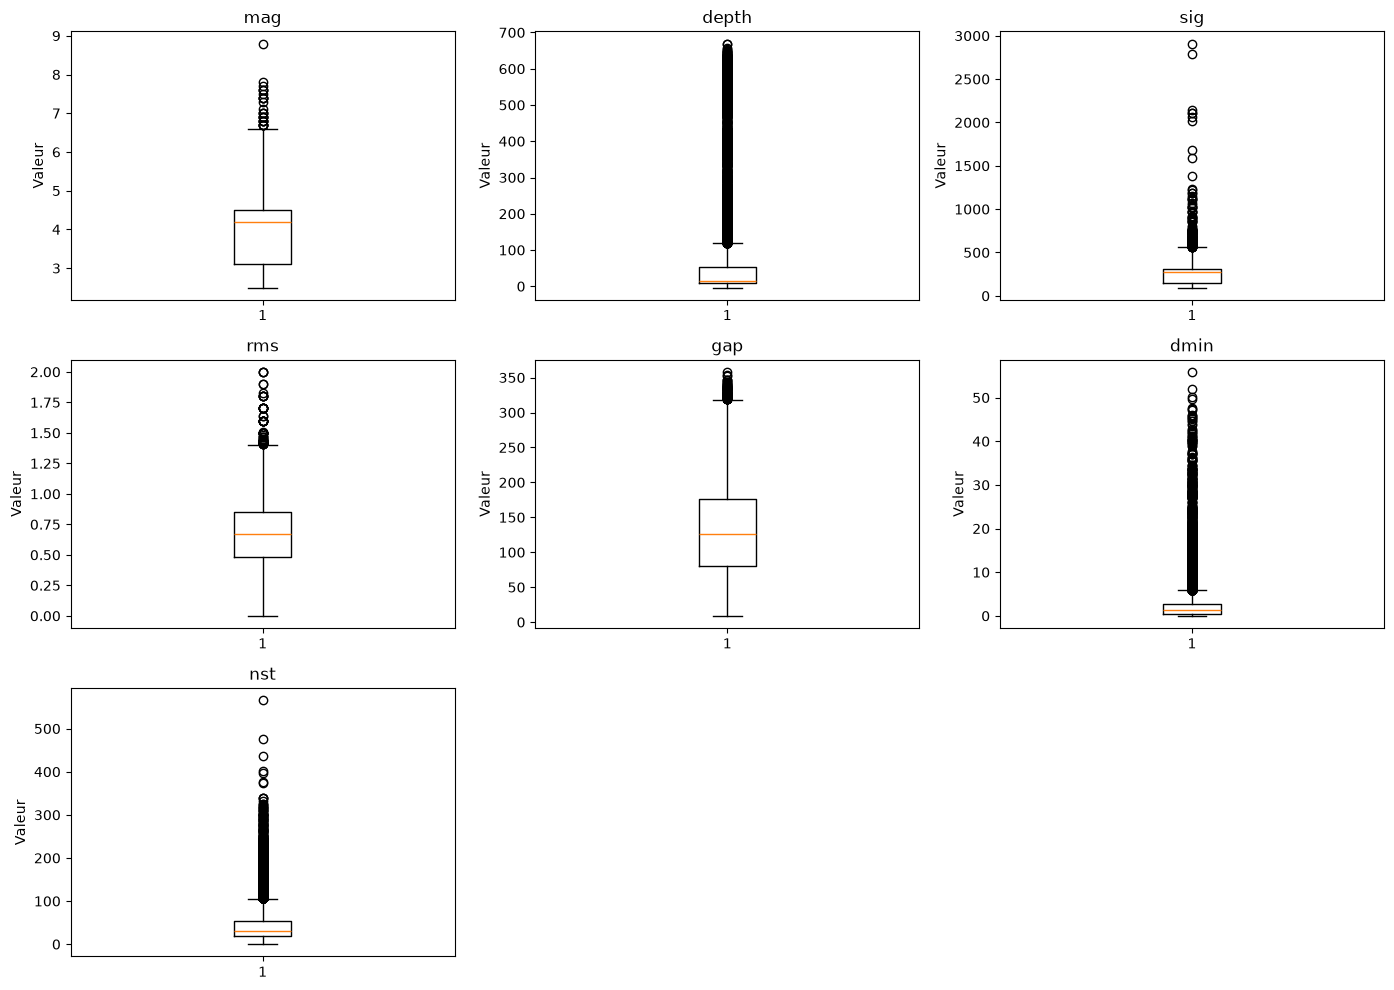

In [13]:
# Variables numériques principales à analyser

variables = [
    "mag",
    "depth",
    "sig",
    "rms",
    "gap",
    "dmin",
    "nst"
]

plt.figure(figsize=(14, 10))

for i, variable in enumerate(variables, 1):
    plt.subplot(3, 3, i)
    plt.boxplot(df[variable].dropna())
    plt.title(variable)
    plt.ylabel("Valeur")

plt.tight_layout()
plt.show()

In [14]:
# Détection des valeurs aberrantes potentielles avec la méthode IQR

for variable in variables:

    data = df[variable].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1

    borne_inferieure = Q1 - 1.5 * IQR
    borne_superieure = Q3 + 1.5 * IQR

    outliers = data[
        (data < borne_inferieure) |
        (data > borne_superieure)
    ]

    print(variable)
    print("  Borne inférieure :", round(borne_inferieure, 3))
    print("  Borne supérieure :", round(borne_superieure, 3))
    print("  Valeurs potentielles aberrantes :", len(outliers))
    print()

mag
  Borne inférieure : 1.0
  Borne supérieure : 6.6
  Valeurs potentielles aberrantes : 29

depth
  Borne inférieure : -55.7
  Borne supérieure : 119.5
  Valeurs potentielles aberrantes : 3404

sig
  Borne inférieure : -98.0
  Borne supérieure : 558.0
  Valeurs potentielles aberrantes : 205

rms
  Borne inférieure : -0.075
  Borne supérieure : 1.405
  Valeurs potentielles aberrantes : 66

gap
  Borne inférieure : -61.5
  Borne supérieure : 318.5
  Valeurs potentielles aberrantes : 91

dmin
  Borne inférieure : -2.709
  Borne supérieure : 5.891
  Valeurs potentielles aberrantes : 2032

nst
  Borne inférieure : -31.0
  Borne supérieure : 105.0
  Valeurs potentielles aberrantes : 1983



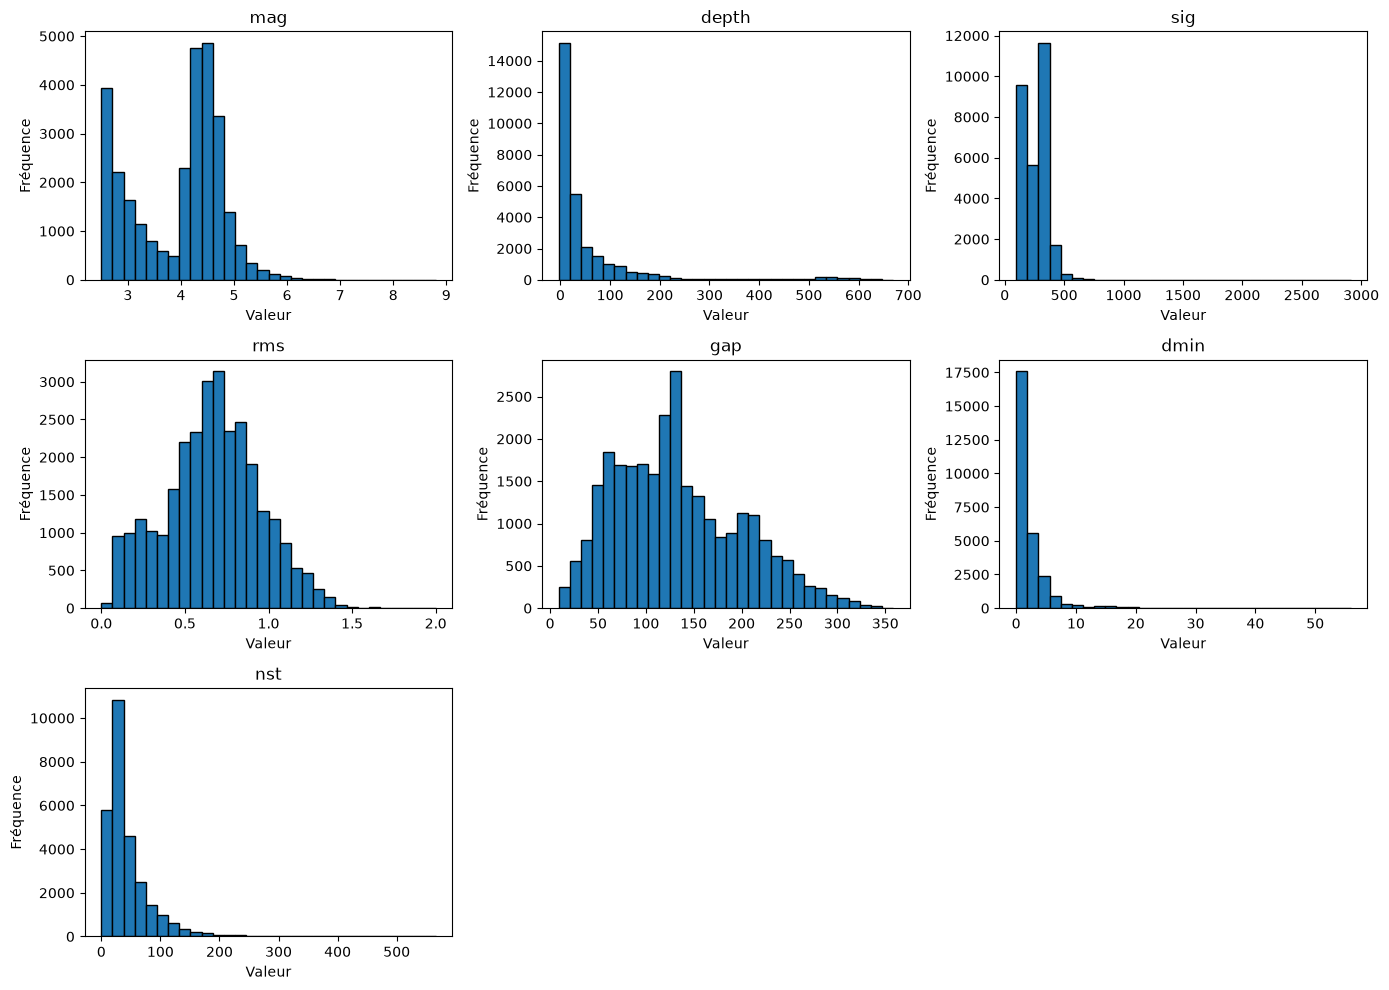

In [16]:
# Distribution des principales variables numériques

variables = [
    "mag",
    "depth",
    "sig",
    "rms",
    "gap",
    "dmin",
    "nst"
]

plt.figure(figsize=(14, 10))

for i, variable in enumerate(variables, 1):

    plt.subplot(3, 3, i)

    plt.hist(
        df[variable].dropna(),
        bins=30,
        edgecolor="black"
    )

    plt.title(variable)
    plt.xlabel("Valeur")
    plt.ylabel("Fréquence")

plt.tight_layout()
plt.show()

In [17]:
# Sélection des variables numériques utiles pour l'analyse

variables_corr = [
    "mag",
    "depth",
    "sig",
    "rms",
    "gap",
    "dmin",
    "nst",
    "felt",
    "cdi",
    "mmi",
    "tsunami",
    "longitude",
    "latitude"
]

# Calcul de la matrice de corrélation
correlation = df[variables_corr].corr()

correlation.round(2)

,mag,depth,sig,rms,gap,dmin,nst,felt,cdi,mmi,tsunami,longitude,latitude
mag,1.00,0.14,0.93,0.40,-0.38,0.34,0.43,0.02,0.34,0.28,0.12,0.62,-0.47
depth,0.14,1.00,0.10,0.04,-0.10,0.06,0.04,-0.02,-0.10,-0.14,-0.01,-0.02,-0.30
sig,0.93,0.10,1.00,0.33,-0.39,0.30,0.49,0.18,0.46,0.42,0.20,0.53,-0.41
rms,0.40,0.04,0.33,1.00,-0.18,0.11,0.06,-0.04,0.09,0.06,0.03,0.25,-0.07
gap,-0.38,-0.10,-0.39,-0.18,1.00,-0.11,-0.43,-0.05,-0.25,-0.42,-0.07,-0.23,0.22
dmin,0.34,0.06,0.30,0.11,-0.11,1.00,0.01,-0.03,0.03,-0.34,-0.02,0.12,-0.42
nst,0.43,0.04,0.49,0.06,-0.43,0.01,1.00,0.05,0.29,0.19,0.19,0.14,0.03
felt,0.02,-0.02,0.18,-0.04,-0.05,-0.03,0.05,1.00,0.08,0.08,0.18,-0.04,0.04
cdi,0.34,-0.10,0.46,0.09,-0.25,0.03,0.29,0.08,1.00,0.65,0.18,0.17,-0.05
mmi,0.28,-0.14,0.42,0.06,-0.42,-0.34,0.19,0.08,0.65,1.00,0.19,0.24,0.07


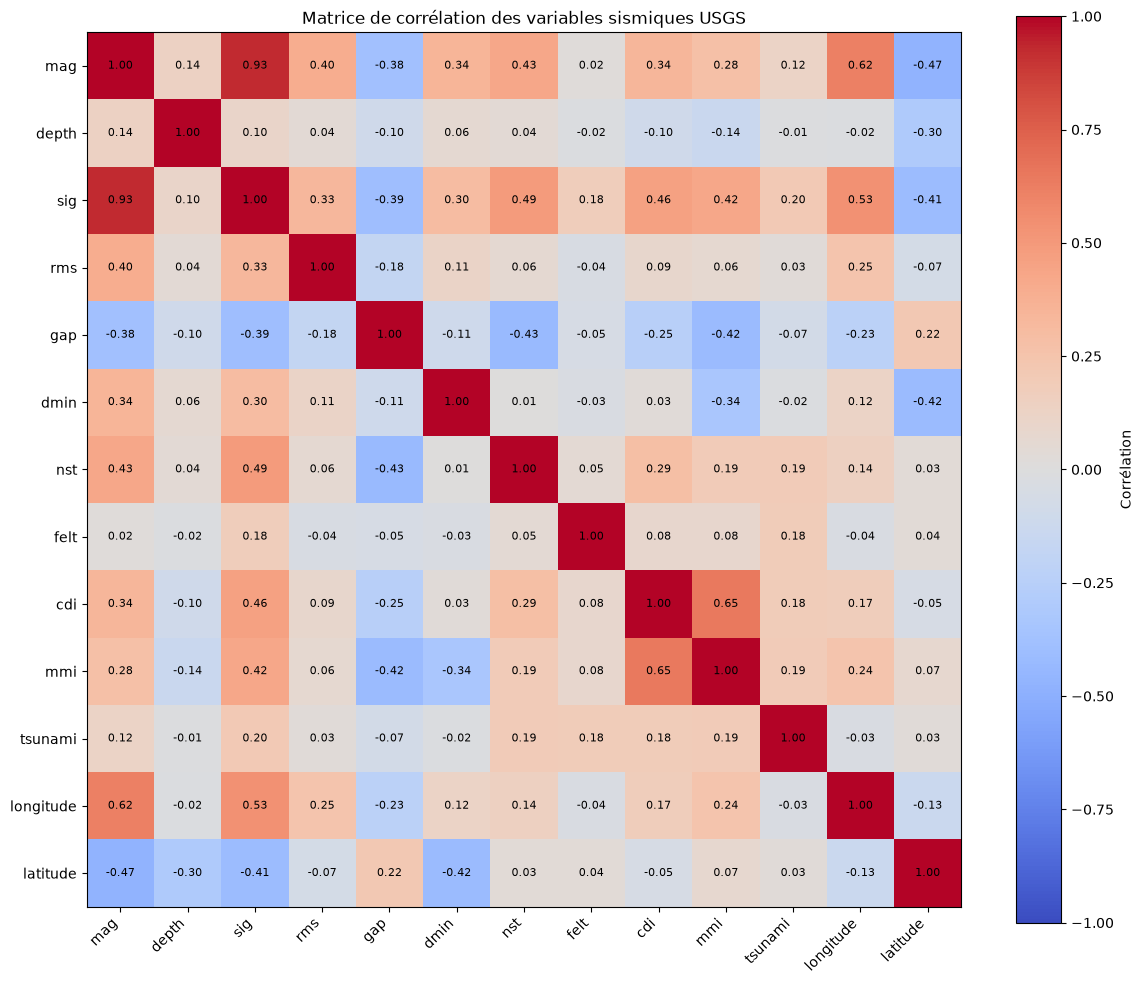

In [18]:
# Visualisation de la matrice de corrélation

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(variables_corr)))
ax.set_yticks(range(len(variables_corr)))

ax.set_xticklabels(variables_corr, rotation=45, ha="right")
ax.set_yticklabels(variables_corr)

# Afficher les coefficients dans les cases
for i in range(len(variables_corr)):
    for j in range(len(variables_corr)):
        ax.text(
            j, i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(im, label="Corrélation")
plt.title("Matrice de corrélation des variables sismiques USGS")
plt.tight_layout()
plt.show()

### Interprétation de la matrice de corrélation

La matrice de corrélation met en évidence plusieurs relations entre les variables sismiques.

- **Magnitude – Significance (sig) : 0.93**  
  Très forte corrélation positive. Les séismes de magnitude élevée ont généralement une importance USGS (`sig`) plus élevée.

- **CDI – MMI : 0.65**  
  Corrélation positive relativement forte entre l'intensité ressentie rapportée par les utilisateurs (CDI) et l'intensité instrumentale MMI.

- **Magnitude – NST : 0.43**  
  Relation positive modérée entre la magnitude et le nombre de stations utilisées pour déterminer la localisation du séisme.

- **Magnitude – RMS : 0.40**  
  Corrélation positive modérée.

- **Magnitude – GAP : -0.38**  
  Relation négative modérée.

Certaines corrélations avec la latitude et la longitude sont également observées. Elles doivent cependant être interprétées avec prudence, car elles peuvent dépendre de la répartition géographique des événements présents dans l'échantillon.

La corrélation permet d'identifier des relations linéaires entre variables mais ne démontre pas une relation de causalité.

In [19]:
# Conversion des dates USGS

df["date_time"] = pd.to_datetime(
    df["time"],
    unit="ms",
    utc=True
)

df["year"] = df["date_time"].dt.year
df["month"] = df["date_time"].dt.month
df["day"] = df["date_time"].dt.day
df["hour"] = df["date_time"].dt.hour

df[
    ["time", "date_time", "year", "month", "day", "hour"]
].head()

,time,date_time,year,month,day,hour
0,1751241591065,2025-06-29 23:59:51.065000+00:00,2025,6,29,23
1,1751241495097,2025-06-29 23:58:15.097000+00:00,2025,6,29,23
2,1751241219318,2025-06-29 23:53:39.318000+00:00,2025,6,29,23
3,1751241150341,2025-06-29 23:52:30.341000+00:00,2025,6,29,23
4,1751240317514,2025-06-29 23:38:37.514000+00:00,2025,6,29,23


In [20]:
# Sauvegarde du dataset préparé

output_path = "../data/usgs_earthquakes_2025.csv"

df.to_csv(
    output_path,
    index=False
)

print("Dataset sauvegardé :", output_path)
print("Nombre de lignes :", len(df))
print("Nombre de colonnes :", len(df.columns))

Dataset sauvegardé : ../data/usgs_earthquakes_2025.csv
Nombre de lignes : 29062
Nombre de colonnes : 35


In [21]:
# Vérification du dataset sauvegardé

df_check = pd.read_csv("../data/usgs_earthquakes_2025.csv")

print("Dimensions :", df_check.shape)
print("Nombre de lignes :", len(df_check))
print("Nombre de colonnes :", len(df_check.columns))

df_check.head()

Dimensions : (29062, 35)
Nombre de lignes : 29062
Nombre de colonnes : 35


,mag,place,time,updated,tz,url,detail,felt,cdi,mmi,...,title,longitude,latitude,depth,event_id,date_time,year,month,day,hour
0,4.2,"70 km W of Abra Pampa, Argentina",1751241591065,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,...,"M 4.2 - 70 km W of Abra Pampa, Argentina",-66.3753,-22.6251,247.528,us7000q9mu,2025-06-29 23:59:51.065000+00:00,2025,6,29,23
1,2.5,"1 km E of Nikolski, Alaska",1751241495097,1757018405040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,...,"M 2.5 - 1 km E of Nikolski, Alaska",-168.8412,52.9376,61.149,us7000qb5r,2025-06-29 23:58:15.097000+00:00,2025,6,29,23
2,2.8,"31 km SSE of Nikolski, Alaska",1751241219318,1757018405040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,...,"M 2.8 - 31 km SSE of Nikolski, Alaska",-168.6544,52.6804,35.000,us7000qb5v,2025-06-29 23:53:39.318000+00:00,2025,6,29,23
3,3.8,"153 km S of Nikolski, Alaska",1751241150341,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,...,"M 3.8 - 153 km S of Nikolski, Alaska",-168.5438,51.5761,10.000,us7000q9mt,2025-06-29 23:52:30.341000+00:00,2025,6,29,23
4,4.5,"185 km WSW of Tual, Indonesia",1751240317514,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,...,"M 4.5 - 185 km WSW of Tual, Indonesia",131.2977,-6.4544,35.000,us7000q9mq,2025-06-29 23:38:37.514000+00:00,2025,6,29,23
